# Analyze results from phyloglm

In [8]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
stage04_path = os.path.join(repo_root, "scripts", "04_permulation_loss_dup")
for path in (src_path, stage04_path):
    if path not in sys.path:
        sys.path.insert(0, path)

results_path = os.path.join(repo_root, "results")

print(f"Using src path: {src_path}")
print(f"Using stage-04 path: {stage04_path}")

# Import modules
import odds_ratio_test as ort

%load_ext autoreload

Using src path: /Users/calvin/orb-selection/src
Using stage-04 path: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
pglm_df = pd.read_csv(f"{results_path}/phyloglm/phyloglm_qvals.csv", index_col="HOG")

In [13]:
pglm_df.shape[0]

12096

In [24]:
sig_pglm = pglm_df[pglm_df["qvalue"] < 0.05].sort_values("qvalue")

print("Significant HOGs by PhyloGLM:", sig_pglm.shape[0])

Significant HOGs by PhyloGLM: 2507


In [12]:
sig_pglm.head()

,error,coef_.Intercept._Estimate,coef_.Intercept._StdErr,coef_.Intercept._z.value,coef_.Intercept._p.value,coef_orb_weavingTRUE_Estimate,coef_orb_weavingTRUE_StdErr,coef_orb_weavingTRUE_z.value,coef_orb_weavingTRUE_p.value,qvalue
HOG,,,,,,,,,,
N5.HOG0067161,NaN,-0.131217,0.111454,-1.177318,0.239069,0.462570,0.050010,9.249622,2.252871e-20,1.915639e-16
N5.HOG0062479,NaN,-0.102667,0.072843,-1.409441,0.158705,0.283759,0.032246,8.799725,1.371518e-18,5.831077e-15
N5.HOG0068083,NaN,-0.116300,0.102023,-1.139940,0.254311,0.391135,0.045379,8.619335,6.734435e-18,1.908786e-14
N5.HOG0068230,NaN,0.118418,0.062018,1.909418,0.056208,-0.274228,0.032937,-8.325893,8.369532e-17,1.779174e-13
N5.HOG0030400,NaN,1.146628,0.302901,3.785491,0.000153,-1.144605,0.137932,-8.298313,1.056000e-16,1.795855e-13


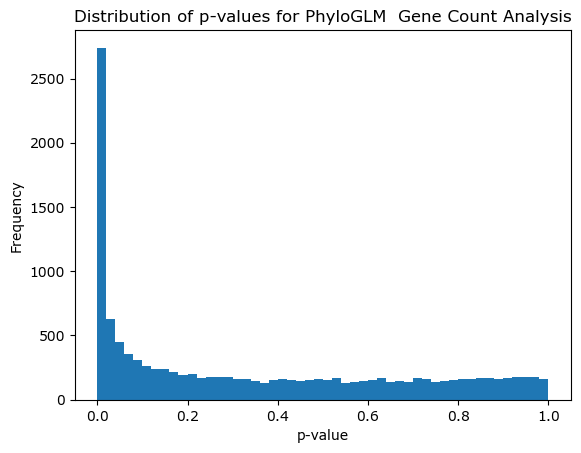

In [14]:
plt.hist(pglm_df["coef_orb_weavingTRUE_p.value"], bins=50)
plt.title("Distribution of p-values for PhyloGLM  Gene Count Analysis")
plt.xlabel("p-value")
plt.ylabel("Frequency")
plt.show()

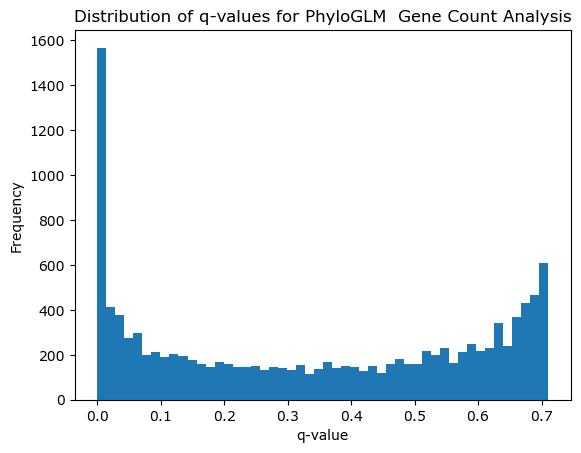

In [15]:
plt.hist(pglm_df["qvalue"], bins=50)
plt.title("Distribution of q-values for PhyloGLM  Gene Count Analysis")
plt.xlabel("q-value")
plt.ylabel("Frequency")
plt.show()

### Investigate overlap with log odds ratio permulation test

In [25]:
loss_res_perm = pd.read_csv(f"{repo_root}/results/odds_ratio_test/Results_Jul22/Run1_occ_30-88_10000x/perm_loss_pvalues.csv", index_col="HOG")
dup_res_perm = pd.read_csv(f"{repo_root}/results/odds_ratio_test/Results_Jul22/Run1_occ_30-88_10000x/perm_dup_pvalues.csv", index_col="HOG")

In [26]:
all_sig_perm = pd.read_csv(f"{repo_root}/results/odds_ratio_test/Results_Jul22/Run1_occ_30-88_10000x/fltrd_hits.csv", index_col="HOG")

In [27]:
loss_fg_sig_perm = all_sig_perm[all_sig_perm["Significant by permulation"].str.contains("loss_fg", na=False)]
loss_bg_sig_perm = all_sig_perm[all_sig_perm["Significant by permulation"].str.contains("loss_bg", na=False)]
dup_fg_sig_perm = all_sig_perm[all_sig_perm["Significant by permulation"].str.contains("dup_fg", na=False)]
dup_bg_sig_perm = all_sig_perm[all_sig_perm["Significant by permulation"].str.contains("dup_bg", na=False)]

print("Loss Foreground Significant by Permulation:", loss_fg_sig_perm.shape[0])
print("Loss Background Significant by Permulation:", loss_bg_sig_perm.shape[0])
print("Duplicate Foreground Significant by Permulation:", dup_fg_sig_perm.shape[0])
print("Duplicate Background Significant by Permulation:", dup_bg_sig_perm.shape[0])

Loss Foreground Significant by Permulation: 215
Loss Background Significant by Permulation: 406
Duplicate Foreground Significant by Permulation: 464
Duplicate Background Significant by Permulation: 514


In [28]:
loss_fg_sig_perm_thresh = loss_fg_sig_perm[loss_fg_sig_perm["Significant by avgd thresholds"].str.contains("loss_fg", na=False)].shape[0]
loss_bg_sig_perm_thresh = loss_bg_sig_perm[loss_bg_sig_perm["Significant by avgd thresholds"].str.contains("loss_bg", na=False)].shape[0]
dup_fg_sig_perm_thresh = dup_fg_sig_perm[dup_fg_sig_perm["Significant by avgd thresholds"].str.contains("dup_fg", na=False)].shape[0]
dup_bg_sig_perm_thresh = dup_bg_sig_perm[dup_bg_sig_perm["Significant by avgd thresholds"].str.contains("dup_bg", na=False)].shape[0]

print("Loss Foreground Significant by Permulation and Thresholds:", loss_fg_sig_perm_thresh)
print("Loss Background Significant by Permulation and Thresholds:", loss_bg_sig_perm_thresh)
print("Duplicate Foreground Significant by Permulation and Thresholds:", dup_fg_sig_perm_thresh)
print("Duplicate Background Significant by Permulation and Thresholds:", dup_bg_sig_perm_thresh)


Loss Foreground Significant by Permulation and Thresholds: 44
Loss Background Significant by Permulation and Thresholds: 169
Duplicate Foreground Significant by Permulation and Thresholds: 149
Duplicate Background Significant by Permulation and Thresholds: 150


In [29]:
sig_pglm_orb = sig_pglm[sig_pglm["coef_orb_weavingTRUE_Estimate"] > 0]
sig_pglm_nonorb = sig_pglm[sig_pglm["coef_orb_weavingTRUE_Estimate"] < 0]
print("Foreground Significant by PhyloGLM:", sig_pglm_orb.shape[0])
print("Background Significant by PhyloGLM:", sig_pglm_nonorb.shape[0])

Foreground Significant by PhyloGLM: 1327
Background Significant by PhyloGLM: 1180


In [30]:
overlap_loss_fg_df = loss_fg_sig_perm.merge(sig_pglm, left_index=True, right_index=True, suffixes=('_perm', '_pglm'))
overlap_loss_bg_df = loss_bg_sig_perm.merge(sig_pglm, left_index=True, right_index=True, suffixes=('_perm', '_pglm'))
overlap_dup_fg_df = dup_fg_sig_perm.merge(sig_pglm, left_index=True, right_index=True, suffixes=('_perm', '_pglm'))
overlap_dup_bg_df = dup_bg_sig_perm.merge(sig_pglm, left_index=True, right_index=True, suffixes=('_perm', '_pglm'))

print("Overlap Loss Foreground Significant by Both:", overlap_loss_fg_df.shape[0])
print("Overlap Loss Background Significant by Both:", overlap_loss_bg_df.shape[0])
print("Overlap Duplication Foreground Significant by Both:", overlap_dup_fg_df.shape[0])
print("Overlap Duplication Background Significant by Both:", overlap_dup_bg_df.shape[0])

Overlap Loss Foreground Significant by Both: 58
Overlap Loss Background Significant by Both: 112
Overlap Duplication Foreground Significant by Both: 142
Overlap Duplication Background Significant by Both: 169


In [31]:
overlap_all_df = all_sig_perm.merge(sig_pglm, left_index=True, right_index=True, suffixes=('_perm', '_pglm'))
overlap_all_df

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant by avgd thresholds,Significant by permulation,error,coef_.Intercept._Estimate,coef_.Intercept._StdErr,coef_.Intercept._z.value,coef_.Intercept._p.value,coef_orb_weavingTRUE_Estimate,coef_orb_weavingTRUE_StdErr,coef_orb_weavingTRUE_z.value,coef_orb_weavingTRUE_p.value,qvalue
HOG,,,,,,,,,,,,,,,,,,,
N5.HOG0002163,62,-0.927049,0.845076,0.9953,0.0047,0.1154,0.8846,NaN,loss_bg,NaN,-0.558401,0.383995,-1.454189,0.145894,0.869823,0.190683,4.561625,5.075914e-06,1.240259e-04
N5.HOG0002298,30,-2.700648,1.279728,0.9966,0.0034,0.2920,0.7080,NaN,loss_bg,NaN,-1.405559,0.514490,-2.731949,0.006296,0.771913,0.248109,3.111186,1.863377e-03,1.125318e-02
N5.HOG0002341,62,2.049581,-2.986536,0.3537,0.6463,0.9886,0.0114,dup_bg,dup_bg,NaN,0.157316,0.241555,0.651266,0.514875,-0.458361,0.145451,-3.151313,1.625383e-03,1.017556e-02
N5.HOG0003890,78,-0.339867,1.664091,0.7432,0.2568,0.0350,0.9650,NaN,dup_fg,NaN,-0.303695,0.286084,-1.061559,0.288436,0.374316,0.127063,2.945904,3.220126e-03,1.659303e-02
N5.HOG0003965,36,-3.036253,2.797887,0.9439,0.0561,0.0160,0.9840,dup_fg,dup_fg,NaN,-1.751434,0.698727,-2.506608,0.012190,1.953765,0.310183,6.298744,3.000669e-10,5.751316e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
N5.HOG0072288,41,1.673886,-1.115756,0.0325,0.9675,0.8274,0.1726,NaN,loss_fg,NaN,-0.305364,0.291715,-1.046789,0.295197,-0.422446,0.171134,-2.468506,1.356783e-02,4.710846e-02
N5.HOG0072503,36,0.730963,-1.176316,0.0138,0.9862,0.7195,0.2805,NaN,loss_fg,NaN,-0.242727,0.355872,-0.682062,0.495200,-0.787730,0.277455,-2.839124,4.523752e-03,2.164655e-02
N5.HOG0072637,38,0.680894,-0.780676,0.0233,0.9767,0.7400,0.2600,NaN,loss_fg,NaN,-0.328786,0.428673,-0.766986,0.443090,-1.345691,0.522976,-2.573140,1.007805e-02,3.820325e-02
